In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.float_format', '{:.2f}'.format)

In [3]:
df = pd.read_csv('..\..\data\processed\openfoodfacts_filtered.csv')


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 22 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   nutriscore_grade                      100000 non-null  object 
 1   code                                  100000 non-null  object 
 2   product_name                          98280 non-null   object 
 3   brands                                78871 non-null   object 
 4   categories                            99923 non-null   object 
 5   countries                             99730 non-null   object 
 6   energy_100g                           98284 non-null   float64
 7   energy-kcal_100g                      95636 non-null   float64
 8   fat_100g                              98286 non-null   float64
 9   saturated-fat_100g                    96001 non-null   float64
 10  carbohydrates_100g                    98155 non-null   float64
 11  s

Text(0.5, 1.0, 'Distribution of Target Variable')

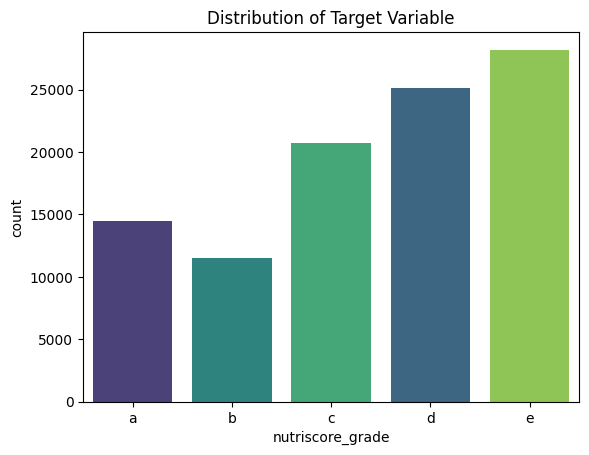

In [5]:
sns.countplot(data=df, x='nutriscore_grade',order=sorted(
    df['nutriscore_grade'].unique()), 
    palette='viridis',hue='nutriscore_grade')

plt.title('Distribution of Target Variable')

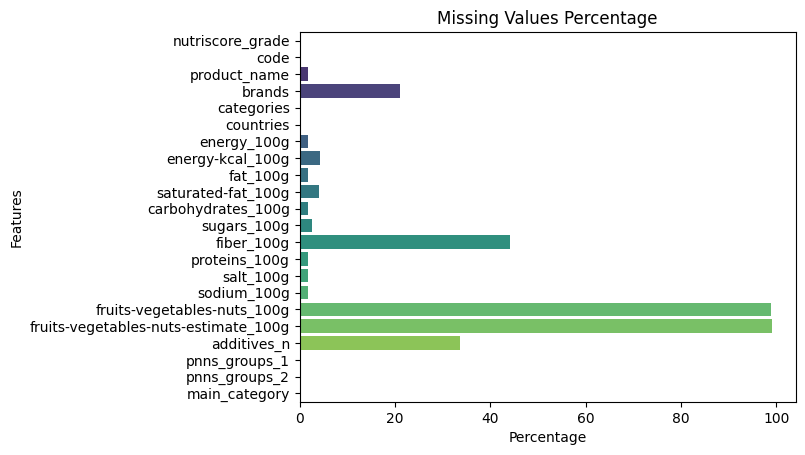

In [6]:
missing_percentage = (df.isnull().sum() / len(df)) * 100
sns.barplot(y=missing_percentage.index, x=missing_percentage.values, 
            palette='viridis',orient='h',hue=missing_percentage.index
            ,legend=False)

plt.title('Missing Values Percentage')
plt.xlabel('Percentage')
plt.ylabel('Features')
plt.show()


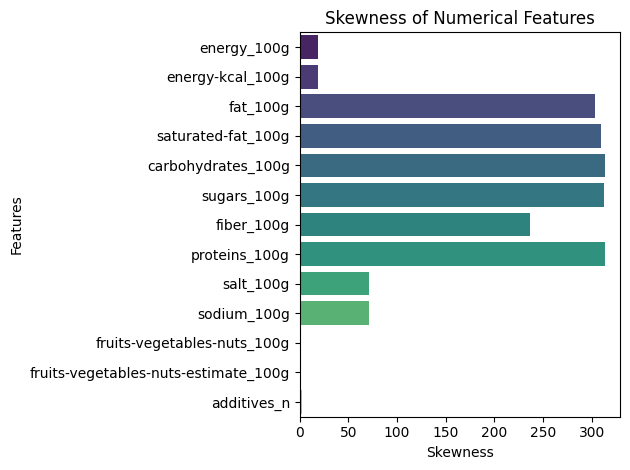

In [7]:
numerical_features = df.select_dtypes(include=[np.number]).columns

sns.barplot(y=numerical_features, x=df[numerical_features].skew(),
            palette='viridis',orient='h',hue=numerical_features,
            legend=False)

plt.title('Skewness of Numerical Features')
plt.xlabel('Skewness')
plt.ylabel('Features')
plt.tight_layout()
plt.show()




**The high skewness is probabily due to to wrong inputs in the dataset, let's check by plotting the highest values of the features with high skewness to check if they're coherent**

In [8]:
display(df[numerical_features].max())

energy_100g                                  134000.00
energy-kcal_100g                              32100.00
fat_100g                                      90937.00
saturated-fat_100g                           992276.00
carbohydrates_100g                          8761109.00
sugars_100g                            765433221122.00
fiber_100g                                   938364.00
proteins_100g                               8578293.00
salt_100g                                      3625.00
sodium_100g                                    1450.00
fruits-vegetables-nuts_100g                     100.00
fruits-vegetables-nuts-estimate_100g            100.00
additives_n                                      36.00
dtype: float64

Invalid values and outlier removal is needed, we will check the skewness after the removal to check.
After the removal a correct imputation strategy is needed.

In [9]:
df = pd.read_csv('..\..\data\processed\openfoodfacts_eda.csv')

In [106]:
from scipy.stats import skew
import pandas as pd

# skewness per colonna numerica
num = df.select_dtypes(include=['number'])
sk = num.apply(lambda col: skew(col.dropna()))
# prime 5 per skewness assoluta (più asimmetriche)
top5 = sk.abs().sort_values(ascending=False).head(5)
print(top5)

sugar_to_carb_ratio                 226.69
fat_to_protein_ratio                125.22
pnns_groups_1_Alcoholic beverages   104.61
countries_en:germany                  9.94
sodium_100g                           9.47
dtype: float64


In [ ]:
n_cols = 3
n_rows = (len(numerical_features) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(numerical_features):

    sns.boxplot(
        data=df, 
        x='nutriscore_grade',       
        y=col,            
        order=['a','b','c','d','e'],
        hue='nutriscore_grade',
        palette='viridis',
        ax=axes[i]        
    )
plt.tight_layout()
plt.show()



KeyboardInterrupt: 